In [ ]:
import random
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
    

Person class

In [ ]:
class Person:
    # Constructor that initialises the name of Person the number of bits/bases/states and the bits/bases/states themselves 
    def __init__(self, name, length):
        self.name = name
        self.length = length
        self.bits = []
        self.bases = []
        self.states = QuantumCircuit(length)
        
    def randomiseBits(self):
        for i in range(self.length):
            self.bits.append(random.choice([0, 1]))
        

    def randomiseBases(self):
        for i in range(self.length):    
            self.bases.append(random.choice([0, 1]))
            # Instead of "Z" and "X" we choose 0 and 1 for simplicity

    # The core logic to deduce quantum states; implemented gates
    def deduceStates(self):
        for i in range(self.length):
            if(self.bits[i] == 1):
                if(self.bases[i] == 1):
                    self.states.x(i)
                    self.states.h(i)
                else:
                    self.states.x(i)
            else:
                if(self.bases[i] == 1):
                    self.states.h(i)

    #  This method is designed for the Receiver who will measure the states received
    def deduceBits(self, array_states):
        for i in range(self.length):
            # By default qiskit measures with Z basis(0)
            # If the chosen basis is X(1) then hadamard gate is applied before measuring
            if(self.bases[i] == 1):
                array_states.h(i)
        
        array_states.measure_all()

        backend = AerSimulator() # Creating an instance of the simulator
        job = backend.run(array_states, shots = 1) # Only one shot because we want the simulation to run just once
        result = job.result()

        counts = result.get_counts()
        # print(counts)
        bit_string = list(counts.keys())[0] # Extracting just the bit(index 0) from the dictionary structure

        # We slice and reverse because Qiskit reads right-to-left(little Enidian)
        reversed_bit_string = bit_string[::-1]

        # We MUST loop through each of the character in the string and convert it to int, because
        # simply putting int(reversed_bits_string) would neglect any leading zeroes!
        self.bits = [int(bit) for bit in reversed_bit_string]


    def display(self):
        print("Bits:", self.bits)
        print("Bases:", self.bases)



Alice

Length of qubits sent:  10
Bits: [0, 0, 0, 1, 1, 1, 0, 1, 1, 0]
Bases: [0, 1, 0, 0, 1, 1, 0, 1, 1, 0]


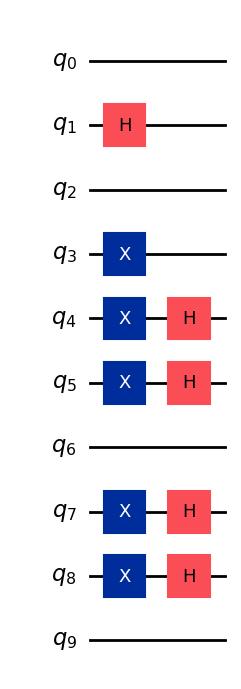

In [94]:
length = 10
print("Length of qubits sent: ", length)
Alice = Person("Alice", length)
Alice.randomiseBits()
Alice.randomiseBases()
Alice.deduceStates()
Alice.display()
Alice.states.draw(output = "mpl")

Bob

In [95]:
# Bob has access to Eve's bases
Bob = Person("Bob", length)
Bob.randomiseBases()
Bob.deduceBits(Alice.states)
Bob.display()


Bits: [1, 0, 0, 1, 1, 0, 0, 0, 1, 0]
Bases: [1, 0, 0, 1, 0, 0, 0, 0, 1, 0]


Sifted Key

In [96]:
otp_alice= []
otp_bob= []
# Alice and Bob publicly share their bases
for i in range(length):
  if(Alice.bases[i] == Bob.bases[i]):
    otp_alice.append(Alice.bits[i])
    otp_bob.append(Bob.bits[i])

print("For Alice: ", otp_alice)
print("For Bob: ", otp_bob)

For Alice:  [0, 0, 1, 0]
For Bob:  [0, 0, 1, 0]


Deducing Error Rate

In [97]:
Match_count  = 0
Sub_length = len(otp_alice)//4 # Comparing first one fourth of one time pad
for i in range(Sub_length):
  if(otp_alice[i] == otp_bob[i]):
    Match_count += 1

print(Match_count)
Error_rate = 100 - ((Match_count/Sub_length)*100)
print("Error Rate: ", Error_rate, "%")

1
Error Rate:  0.0 %
